<a href="https://colab.research.google.com/github/sreejas7919-bit/DSA_6/blob/main/ML_INTERMEDIATE_ASSESSMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [3]:
#read files
train = pd.read_csv("train_LZdllcl.csv")
test = pd.read_csv("test_2umaH9m.csv")
sample = pd.read_csv("sample_submission_M0L0uXE.csv")

In [4]:
train.head()


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [6]:
#shape of train data set and test data set
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (54808, 14)
Test Shape : (23490, 13)


In [7]:
#column information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [8]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [9]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


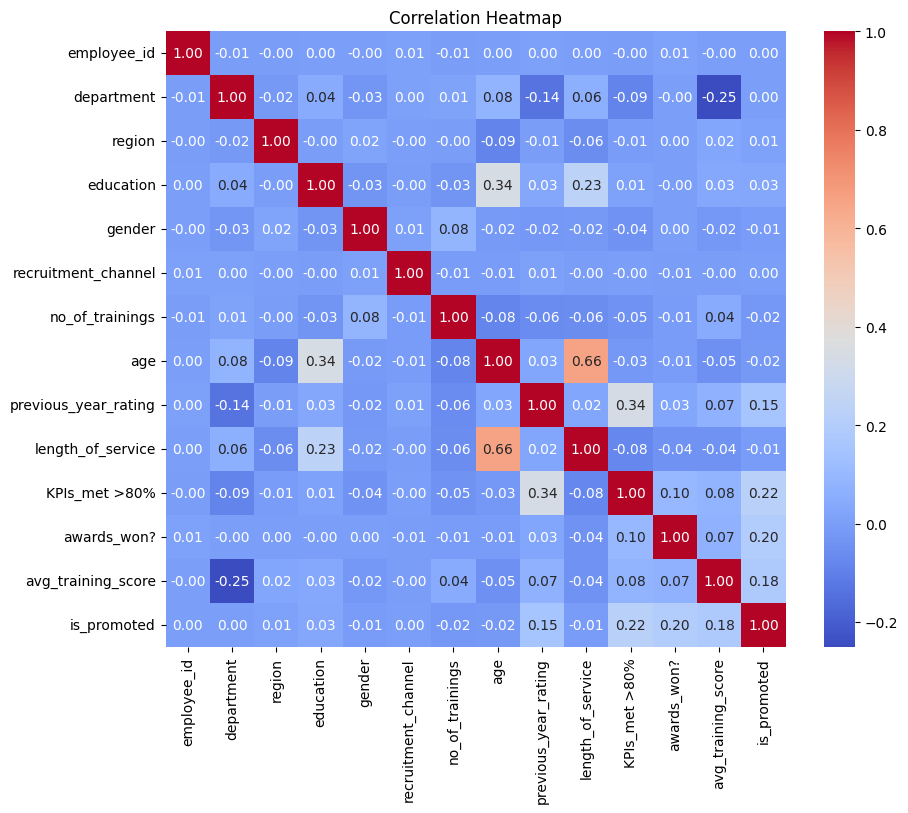

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(train.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
train["is_promoted"].value_counts()

,count
is_promoted,
0,50140
1,4668


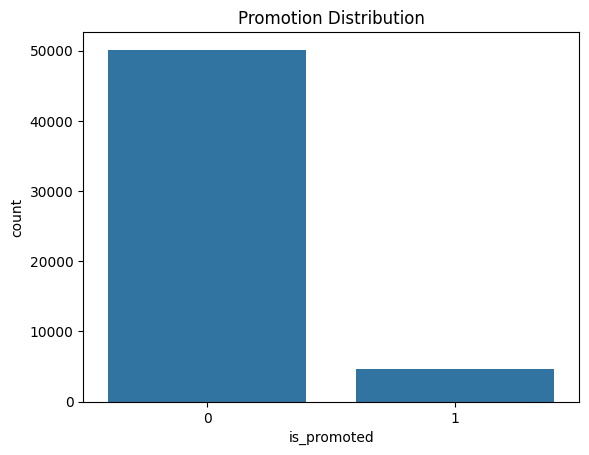

In [12]:
sns.countplot(x="is_promoted", data=train)
plt.title("Promotion Distribution")
plt.show()

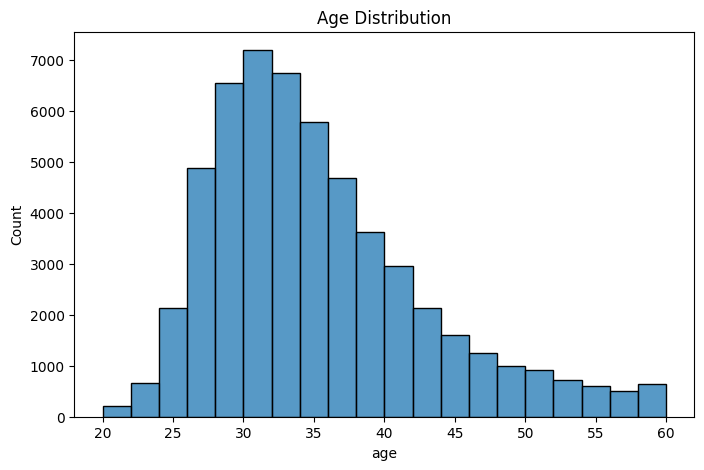

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(train["age"], bins=20)
plt.title("Age Distribution")
plt.show()

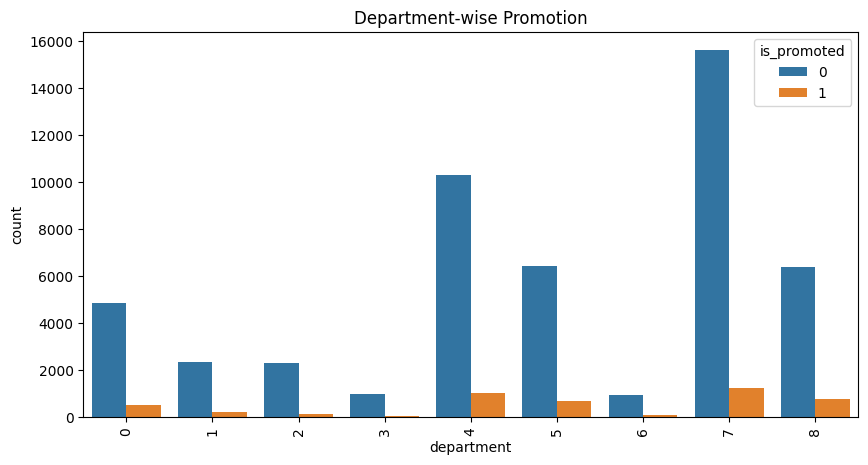

In [32]:
plt.figure(figsize=(10,5))
sns.countplot(x="department", hue="is_promoted", data=train)
plt.xticks(rotation=90)
plt.title("Department-wise Promotion")
plt.show()

EDA COMPLETE

In [13]:
train["education"] = train["education"].fillna(train["education"].mode()[0])
train["previous_year_rating"] = train["previous_year_rating"].fillna(train["previous_year_rating"].median())

test["education"] = test["education"].fillna(test["education"].mode()[0])
test["previous_year_rating"] = test["previous_year_rating"].fillna(test["previous_year_rating"].median())

In [14]:
print(train.isnull().sum())
print(test.isnull().sum())

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64
employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
dtype: int64


In [15]:
#LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["department", "region", "education", "gender", "recruitment_channel"]

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [16]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,7,31,2,0,2,1,35,5.0,8,1,0,49,0
1,65141,4,14,0,1,0,1,30,5.0,4,0,0,60,0
2,7513,7,10,0,1,2,1,34,3.0,7,0,0,50,0
3,2542,7,15,0,1,0,2,39,1.0,10,0,0,50,0
4,48945,8,18,0,1,0,1,45,3.0,2,0,0,73,0


MODELING

In [17]:
#Features (X, y)
X = train.drop(["employee_id", "is_promoted"], axis=1)
y = train["is_promoted"]

X_test = test.drop("employee_id", axis=1)

In [18]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train);


In [21]:
#F1 Score
from sklearn.metrics import f1_score

valid_pred = model.predict(X_valid)

print("F1 Score:", f1_score(y_valid, valid_pred))

F1 Score: 0.42482100238663484


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, valid_pred)

print(cm)

[[9972   56]
 [ 667  267]]


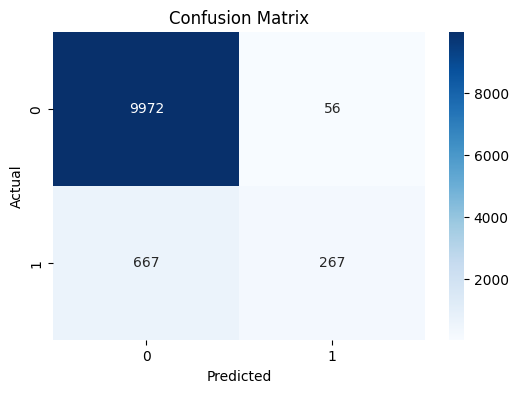

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, valid_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, valid_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.83      0.29      0.42       934

    accuracy                           0.93     10962
   macro avg       0.88      0.64      0.69     10962
weighted avg       0.93      0.93      0.92     10962



In [23]:
test_pred = model.predict(X_test)


In [24]:
sample["is_promoted"] = test_pred

In [25]:
sample.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [33]:
sample.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [34]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>